## Regression Exercise

In [24]:
import numpy as np
import matplotlib.pyplot as plt

pollution_data = np.genfromtxt('data/pollution_cleaneddata.csv', delimiter=',', skip_header=1)

In [25]:
x = pollution_data[:, 10] # POOR
y = pollution_data[:, 15] # MORT
y

array([ 921.87 ,  997.875,  962.354,  982.291, 1071.289, 1030.38 ,
        934.7  ,  899.529, 1001.902,  912.347, 1017.613, 1024.885,
        970.467,  985.95 ,  958.839,  860.101,  936.234,  871.766,
        959.221,  941.181,  891.708,  871.338,  971.122,  887.466,
        952.529,  968.665,  919.729,  844.053,  861.833,  989.265,
       1006.49 ,  861.439,  929.15 ,  857.622,  961.009,  923.234,
       1113.156,  994.648, 1015.023,  991.29 ,  893.991,  938.5  ,
        946.185, 1025.502,  874.281,  953.56 ,  839.709,  911.701,
        790.733,  899.264,  904.155,  950.672,  972.464,  912.202,
        967.803,  823.764, 1003.502,  895.696,  911.817,  954.442])

## LOESS Algorithm

This is how the function works:

1. Select a value on the x-variable $x = x_0$
2. Select the $k$ nearest points to $x_0$
3. Assign a weight to each point $w_i$, this is taken as linear decay from 1 at the center to 0 at the edge.
4. Fit a weighted simple OLS regression by minimising, $\sum w_i (y_0 - \beta_0 - \beta_1 . x_i)^2$, with $\beta_1 ​= \frac {\sum w_i​(x_i ​− x​)(y_i ​− y​)}{\sum w_i​(x_i ​− x​)^2}$​, $\beta_0 ​= y​w​ - \beta_1 .​xw$​
5. The fitted value at $x_0$ is, $y(x_0) = f(x_0) = \beta_0 + \beta_1 . x_0$
6. The variance is calculated by taking $V(y(x_0)) = \sigma^2(\frac{1}{k} + \frac{(x_0 - x)**2}{\sum (x_i ​− x​)^2} + 1)$, where $\sigma^2 = \sum e_i^2 / (k-2)$, with $e_i = y_i - \beta_0 - \beta_1 x_i$.
7. Repeat for different values on $x_0$

In [26]:
def loess(y, x, k, x_0):
    pred = np.zeros(len(x_0))
    sd = np.zeros(len(x_0))

    for i, x0 in enumerate(x_0):

        d = np.abs(x - x0) # distance
        idx = np.argsort(d)[:k] # nearest k
        d_k, x_k, y_k = d[idx], x[idx], y[idx] # nearest point coordinates

        h = d_k.max()
        u = d_k / h if h > 0 else np.zeros(k)

        w = np.clip(1 - u, 0, None) # weighting 1 for centre and 0 for edge

        sum_w = np.sum(w)
        x_bar = np.sum(w * x_k) / sum_w # weighted mean x
        y_bar = np.sum(w * y_k) / sum_w # weighted mean y

        nom = np.sum(w * (x_k - x_bar) * (y_k - y_bar)) # nominator
        denom = np.sum(w * ((x_k - x_bar)** 2)) # denominator
        beta_1 = nom / denom

        beta_0 = y_bar - beta_1 * x_bar

        pred[i] = beta_0 + beta_1 * x0

        e = y_k - (beta_0 + beta_1 * x_k) # e_i
        sigma2 = np.sum(e**2) / (k - 2) # sigma^2

        var_pred = sigma2 * ((1/k) + ((x0 - x_bar)**2 / np.sum((x_k - x_bar)**2)) + 1) # variance
        sd[i] = np.sqrt(max(var_pred, 0))

    return pred, sd


x_0 = np.array([10, 18, 25])
pred, sd = loess(y, x, 30, x_0)
print(f"POOR Values: {x_0}")
print(f"Predicted Values: {pred}")
print(f"Standard Deviation: {sd}")

POOR Values: [10 18 25]
Predicted Values: [ 903.73363477  953.31496661 1009.19700711]
Standard Deviation: [61.00205697 60.20367094 60.10733723]


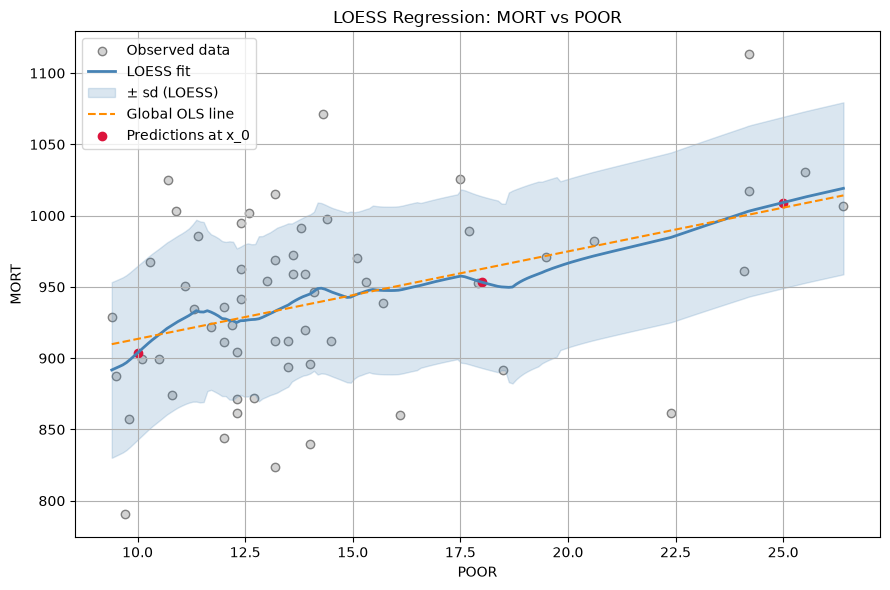

In [27]:
x_grid = np.linspace(x.min(), x.max(), 200) # taking 200 points to get an accurate representation 
pred_grid, sd_grid = loess(y, x, 30, x_grid)

beta1_ols, beta0_ols = np.polyfit(x, y, 1) # global line
y_ols = beta0_ols + beta1_ols * x_grid

plt.figure(figsize=(9, 6))
plt.scatter(x, y, color='lightgray', edgecolor='gray', label='Observed data')
plt.plot(x_grid, pred_grid, color='steelblue', linewidth=2, label='LOESS fit')
plt.fill_between(x_grid, pred_grid - sd_grid, pred_grid + sd_grid, color='steelblue', alpha=0.2, label='± sd (LOESS)')
plt.plot(x_grid, y_ols, color='darkorange', linestyle='--', linewidth=1.5, label='Global OLS line')
plt.scatter(x_0, pred, color='crimson', label='Predictions at x_0')

plt.xlabel('POOR')
plt.ylabel('MORT')
plt.title('LOESS Regression: MORT vs POOR')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()